## CASE STUDY: 
## CUSTOMER ANALYSIS FOR RETAIL 

## Q1. Preparing Dataset

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
Customer= pd.read_csv("M:/DISK M/Python~SS/Assignments/Pandas/Ps-softech Retail Case Study/Customer.csv")
Customer

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0
...,...,...,...,...
5642,274474,19-12-1992,M,2.0
5643,267666,24-12-1992,M,6.0
5644,270476,25-12-1992,F,3.0
5645,269626,27-12-1992,F,5.0


In [70]:
Product_hierarchy= pd.read_csv("M:/DISK M/Python~SS/Assignments/Pandas/Ps-softech Retail Case Study/prod_cat_info.csv")
Product_hierarchy

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women
5,2,Footwear,4,Kids
6,3,Electronics,4,Mobiles
7,3,Electronics,5,Computers
8,3,Electronics,8,Personal Appliances
9,3,Electronics,9,Cameras


In [71]:
Transaction= pd.read_csv("M:/DISK M/Python~SS/Assignments/Pandas/Ps-softech Retail Case Study/Transactions.csv")
Transaction

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop


In [72]:

# 1. Merging
Customer_Trans = pd.merge(left = Customer,
                          right = Transaction,
                          left_on = 'customer_Id',
                          right_on = 'cust_id',
                          how = 'inner',
                          indicator = True)

In [73]:
Customer_Final= pd.merge(Customer_Trans,Product_hierarchy,how='inner',left_on=['prod_cat_code'],right_on=['prod_cat_code'])
print(Customer_Final.columns)
Customer_Final

Index(['customer_Id', 'DOB', 'Gender', 'city_code', 'transaction_id',
       'cust_id', 'tran_date', 'prod_subcat_code', 'prod_cat_code', 'Qty',
       'Rate', 'Tax', 'total_amt', 'Store_type', '_merge', 'prod_cat',
       'prod_sub_cat_code', 'prod_subcat'],
      dtype='str')


,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,_merge,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,7,Fiction
1,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,12,Academic
2,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,10,Non-Fiction
3,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,11,Children
4,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,3,Comics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99288,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.700,3248.700,e-Shop,both,Books,12,Academic
99289,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.700,3248.700,e-Shop,both,Books,10,Non-Fiction
99290,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.700,3248.700,e-Shop,both,Books,11,Children
99291,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.700,3248.700,e-Shop,both,Books,3,Comics


## Q2. Summary Report

Column names with their data-types

In [74]:
Customer_Final.dtypes

customer_Id             int64
DOB                       str
Gender                    str
city_code             float64
transaction_id          int64
cust_id                 int64
tran_date                 str
prod_subcat_code        int64
prod_cat_code           int64
Qty                     int64
Rate                    int64
Tax                   float64
total_amt             float64
Store_type                str
_merge               category
prod_cat                  str
prod_sub_cat_code       int64
prod_subcat               str
dtype: object

Top 10 Observations

In [75]:
Customer_Final.head(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,_merge,prod_cat,prod_sub_cat_code,prod_subcat
0,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,7,Fiction
1,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,12,Academic
2,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,10,Non-Fiction
3,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,11,Children
4,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,3,Comics
5,268408,02-01-1970,M,4.0,87243835584,268408,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,both,Books,6,DIY
6,268408,02-01-1970,M,4.0,16197868036,268408,16-12-2013,1,4,-5,-210,110.250,-1160.250,Flagship store,both,Bags,1,Mens
7,268408,02-01-1970,M,4.0,16197868036,268408,16-12-2013,1,4,-5,-210,110.250,-1160.250,Flagship store,both,Bags,4,Women
8,268408,02-01-1970,M,4.0,16197868036,268408,12/12/2013,1,4,5,210,110.250,1160.250,Flagship store,both,Bags,1,Mens
9,268408,02-01-1970,M,4.0,16197868036,268408,12/12/2013,1,4,5,210,110.250,1160.250,Flagship store,both,Bags,4,Women


Bottom 10 Observations

In [76]:
Customer_Final.tail(10)

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,_merge,prod_cat,prod_sub_cat_code,prod_subcat
99283,274308,29-12-1992,F,5.0,26208690928,274308,22-10-2012,1,2,2,898,188.58,1984.58,MBR,both,Footwear,4,Kids
99284,274308,29-12-1992,F,5.0,57358822237,274308,5/9/2012,1,2,4,876,367.92,3871.92,e-Shop,both,Footwear,1,Mens
99285,274308,29-12-1992,F,5.0,57358822237,274308,5/9/2012,1,2,4,876,367.92,3871.92,e-Shop,both,Footwear,3,Women
99286,274308,29-12-1992,F,5.0,57358822237,274308,5/9/2012,1,2,4,876,367.92,3871.92,e-Shop,both,Footwear,4,Kids
99287,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,7,Fiction
99288,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,12,Academic
99289,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,10,Non-Fiction
99290,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,11,Children
99291,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,3,Comics
99292,274308,29-12-1992,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,6,DIY


“Five-number summary” for continuous variables (min, Q1, median, Q3 and max) 

In [77]:
Customer_Final.total_amt.describe().loc[['min',"25%","50%","75%","max"]]

min   -8270.925
25%     762.450
50%    1761.370
75%    3585.725
max    8287.500
Name: total_amt, dtype: float64

Frequency tables for all the categorical variables

In [78]:
# Categorical Columns
categorical_cols = ['Gender', 'Store_type', 'prod_cat', 'prod_subcat', 'city_code']
# print(categorical_cols)

for col in categorical_cols:
    print(f"\nFrequency Table for {col}")
    print(Customer_Final[col].value_counts())


Frequency Table for Gender
Gender
M    51051
F    48202
Name: count, dtype: int64

Frequency Table for Store_type
Store_type
e-Shop            40185
MBR               19974
Flagship store    19814
TeleShop          19320
Name: count, dtype: int64

Frequency Table for prod_cat
prod_cat
Books               36414
Electronics         24490
Home and kitchen    16516
Footwear             8997
Clothing             8880
Bags                 3996
Name: count, dtype: int64

Frequency Table for prod_subcat
prod_subcat
Mens                   7957
Women                  7957
Fiction                6069
Academic               6069
Non-Fiction            6069
Children               6069
Comics                 6069
DIY                    6069
Kids                   5959
Mobiles                4898
Computers              4898
Personal Appliances    4898
Cameras                4898
Audio and video        4898
Furnishing             4129
Kitchen                4129
Bath                   4129
Tools     

## Q3.Generate histograms for all continuous variables and frequency bars for categorical variables.

Histogram for continous variables -

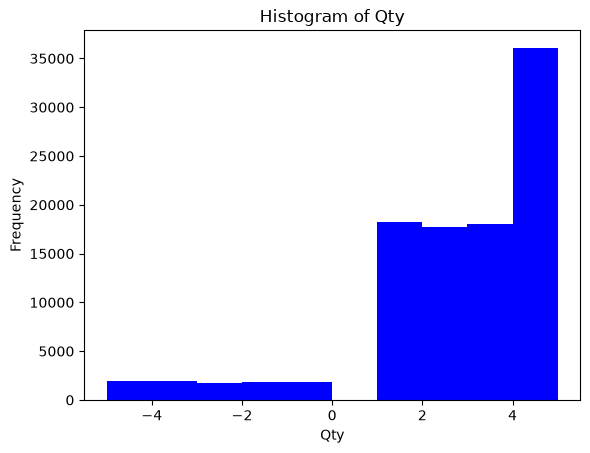

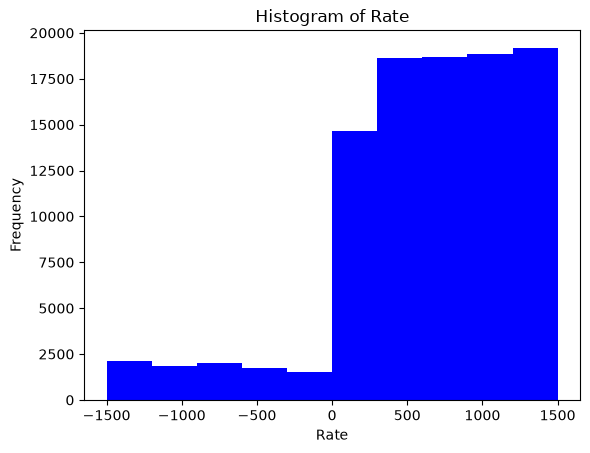

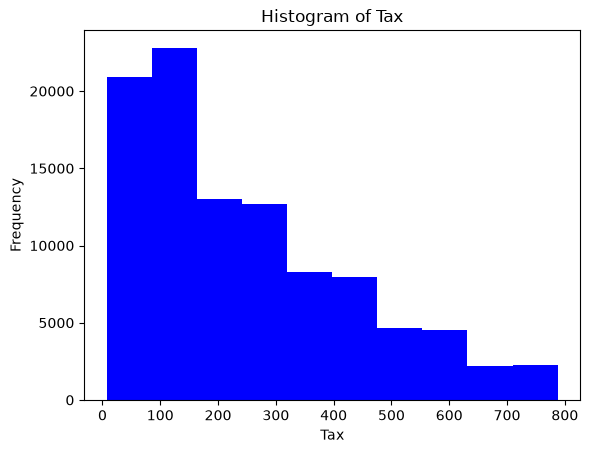

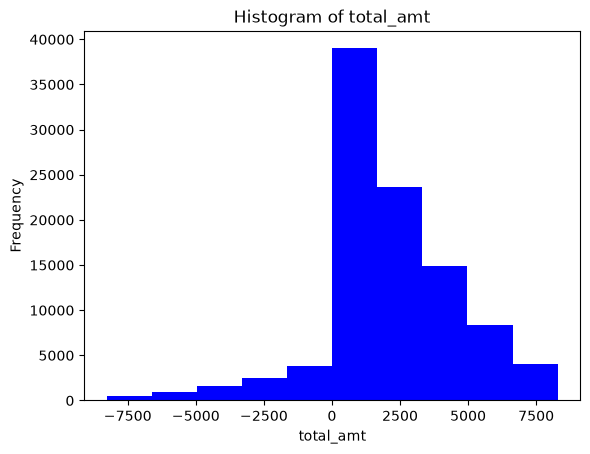

In [79]:
continous_cols = ['Qty', 'Rate', 'Tax', 'total_amt']

for col in continous_cols:
    plt.hist(Customer_Final[col],color="Blue")
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Frequency Bar for Categorical variables -

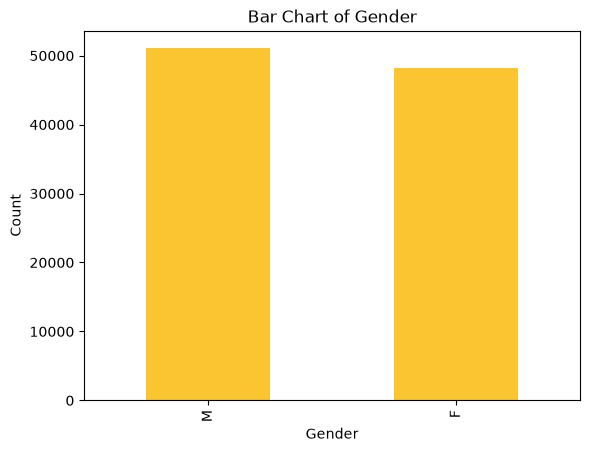

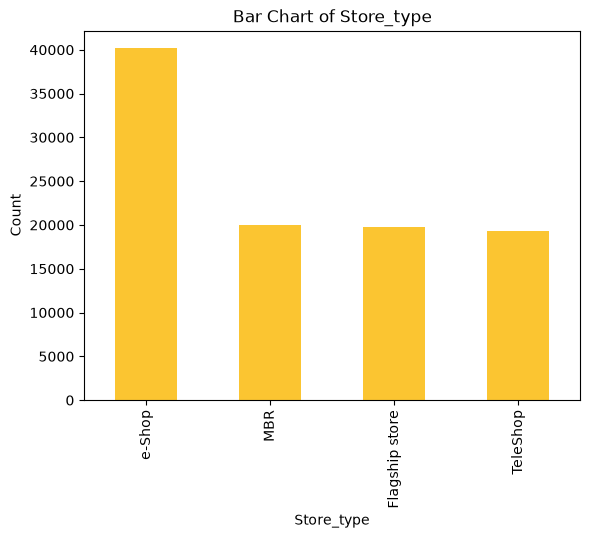

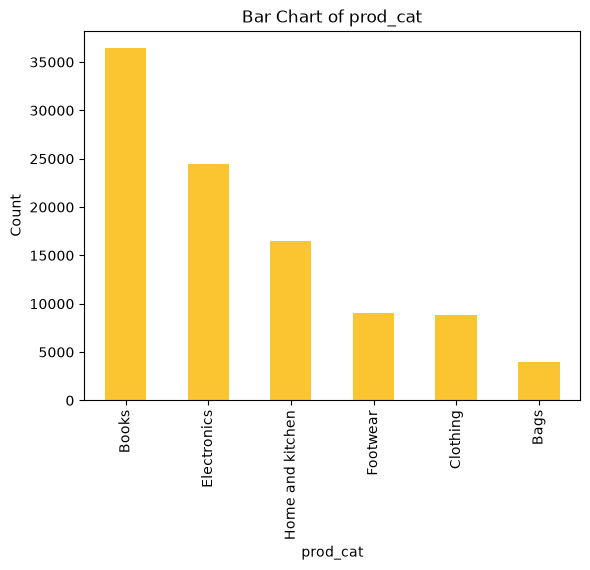

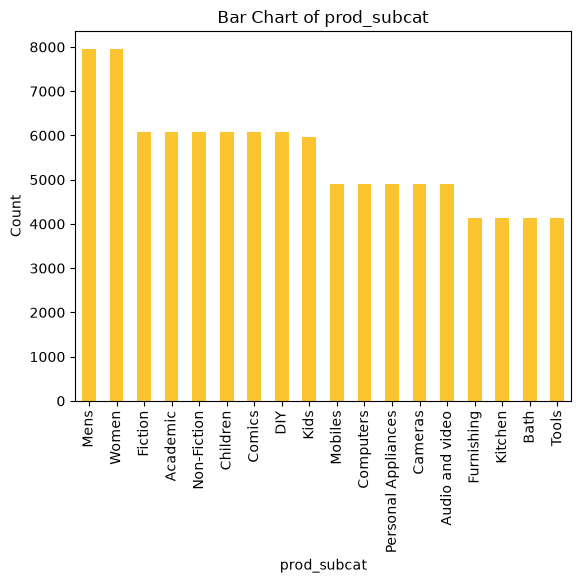

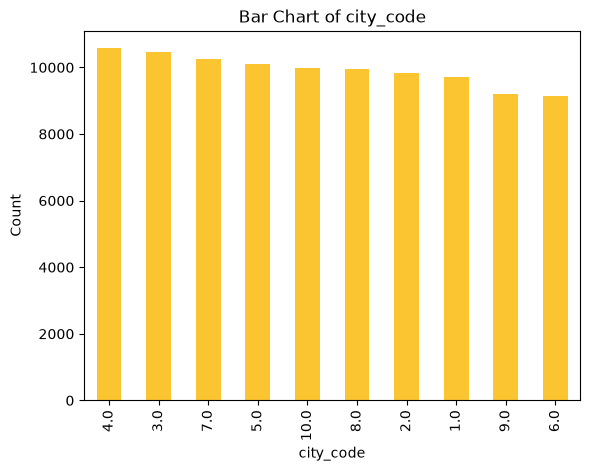

In [92]:
# Categorical Columns
categorical_cols = ['Gender', 'Store_type', 'prod_cat', 'prod_subcat', 'city_code']

for col in categorical_cols:
    Customer_Final[col].value_counts().plot(kind='bar',color='#fbc531')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Q4. Calculate the following information using the merged dataset : 

A. Time period of the available transaction data 

In [81]:
display(f"Start Date : {Customer_Final['tran_date'].min()}")
display(f"Last Date : {Customer_Final['tran_date'].max()}")

'Start Date : 1/1/2012'

'Last Date : 9/9/2013'

B. Count number of negative total amount

In [82]:
print(f"Negative transaction : {(Customer_Final['total_amt'] < 0).sum()}")

Negative transaction : 9294


## Q5. Analyze which product categories are more popular among females vs male customers.

In [83]:
result=pd.crosstab(Customer_Final['Gender'],Customer_Final['prod_cat']).idxmax(axis=1)
display("Most popular categories among M and F :",result)

'Most popular categories among M and F :'

Gender
F    Books
M    Books
dtype: str

## Q6. Which City code has the maximum customers and what was the percentage of customers from that city? 

In [84]:
city_code=Customer_Final['city_code'].value_counts()
print(city_code)
print(f"City code with the maximum customer : {city_code.idxmax()}")

perc_cust=city_code.max()/city_code.sum() *100
print(f"Percentage of customers from that city {perc_cust:.2f}")

city_code
4.0     10571
3.0     10467
7.0     10258
5.0     10116
10.0     9976
8.0      9965
2.0      9843
1.0      9717
9.0      9214
6.0      9130
Name: count, dtype: int64
City code with the maximum customer : 4.0
Percentage of customers from that city 10.65


## Q7. Which store type sells the maximum products by value and by quantity?

In [85]:
value=Customer_Final.groupby('Store_type')['total_amt'].sum().idxmax()
print(value,"store type sells the maximum products by value")

qty=Customer_Final.groupby('Store_type')['Qty'].sum().idxmax()
print(qty,"store type sells the maximum products by quantity")

e-Shop store type sells the maximum products by value
e-Shop store type sells the maximum products by quantity


## Q8. What was the total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?

In [86]:
total = Customer_Final.query("Store_type == 'Flagship store' and prod_cat in ['Electronics', 'Clothing']")['total_amt'].sum()                    # IN 
print("Total Amount : ",total)

Total Amount :  14658949.89


## Q9. What was the total amount earned from "Male" customers under the "Electronics" category?

In [87]:
total=Customer_Final.query('Gender=="M" and prod_cat=="Electronics"')['total_amt'].sum()                 
print("Total Amount : ",round(total,2))

Total Amount :  28515547.12


## 10. How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts? 

In [88]:
k=Customer_Final[Customer_Final['total_amt'] > 0]
k=k.groupby(['customer_Id'])['transaction_id'].count()

print('Total customers having more than 10 unique transactions are - ',(k > 10).sum())

Total customers having more than 10 unique transactions are -  4019


## Q11. For all customers aged between 25 - 35, find out:

In [89]:
Customer_Final['DOB']=pd.to_datetime(Customer_Final['DOB'],dayfirst=True)                 # change dob date into correct format
# Customer_Final

Customer_Final['Age']=pd.Timestamp.now().year- Customer_Final['DOB'].dt.year              # find age 
# Customer_Final

l=Customer_Final.query("Age>=25 and Age<=35")                                       # filter customer between the age of 25 & 35
l

,customer_Id,DOB,Gender,city_code,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type,_merge,prod_cat,prod_sub_cat_code,prod_subcat,Age
90700,269660,1991-01-01,F,6.0,24100230294,269660,18-09-2011,2,6,5,1126,591.15,6221.15,TeleShop,both,Home and kitchen,2,Furnishing,35
90701,269660,1991-01-01,F,6.0,24100230294,269660,18-09-2011,2,6,5,1126,591.15,6221.15,TeleShop,both,Home and kitchen,10,Kitchen,35
90702,269660,1991-01-01,F,6.0,24100230294,269660,18-09-2011,2,6,5,1126,591.15,6221.15,TeleShop,both,Home and kitchen,11,Bath,35
90703,269660,1991-01-01,F,6.0,24100230294,269660,18-09-2011,2,6,5,1126,591.15,6221.15,TeleShop,both,Home and kitchen,12,Tools,35
90704,275242,1991-01-04,F,10.0,17226557489,275242,7/8/2011,4,2,1,138,14.49,152.49,e-Shop,both,Footwear,1,Mens,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99288,274308,1992-12-29,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,12,Academic,34
99289,274308,1992-12-29,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,10,Non-Fiction,34
99290,274308,1992-12-29,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,11,Children,34
99291,274308,1992-12-29,F,5.0,58160544337,274308,4/7/2012,12,5,5,588,308.70,3248.70,e-Shop,both,Books,3,Comics,34


a. What was the total amount spent for “Electronics” and “Books” product categories?

In [90]:
total=l.query('prod_cat.isin(["Electronics","Books"])')['total_amt'].sum()
print("Totol Amount=",total)

Totol Amount= 10789584.649999999


b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 
2014? 

In [91]:

l['tran_date']=pd.to_datetime(l['tran_date'],dayfirst=True,format='mixed')           # Convert Transaction date into correct format
l

total=l.query("'2014-01-01' <= tran_date <= '2014-03-01'")['total_amt'].sum()
print("Total Amount=",total)

Total Amount= 970233.095
